In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
import random

random.seed(10)

# Prepare Data

In [158]:
df = pd.read_csv('/kaggle/input/ghg-emission-in-indonesia/NH3-emissions-by-sector.csv')
df.head()

,Category,Agriculture,Buildings,Fuel Exploitation,Industrial Combustion,Power Industry,Processes,Transport,Waste,Total GHG/cap
0,1970,132159670,16612168,31908488,4938001,3653496,1914473,8253790,18447532,1.90
1,1971,133982675,16612168,32250537,4938001,3653226,1928243,8256379,19057394,1.87
2,1972,129240735,17930973,39990990,5324691,3952725,2038089,8903075,19654530,1.88
3,1973,132788547,18916604,48693559,5722832,4194392,2263751,9438943,20370806,1.95
4,1974,133553122,20391057,50885341,6141811,3877281,2540359,10845549,21007323,1.96


In [211]:
data = {}
Kolom = ['Agriculture','Buildings','Fuel Exploitation','Industrial Combustion','Power Industry','Processes','Transport','Waste']
for i in Kolom:
    data[i] = df[i].to_list()

# Plot Data

In [160]:
tahun = [i for i in range(1970,2023)]

In [ ]:
counter = 1
f = plt.figure()
f.set_figwidth(12) 
f.set_figheight(8) 
for i in Kolom:
    plt.subplot(2,4,counter)
    plt.plot(data[i])
    plt.title(i)
    counter += 1
f.tight_layout()
plt.show()

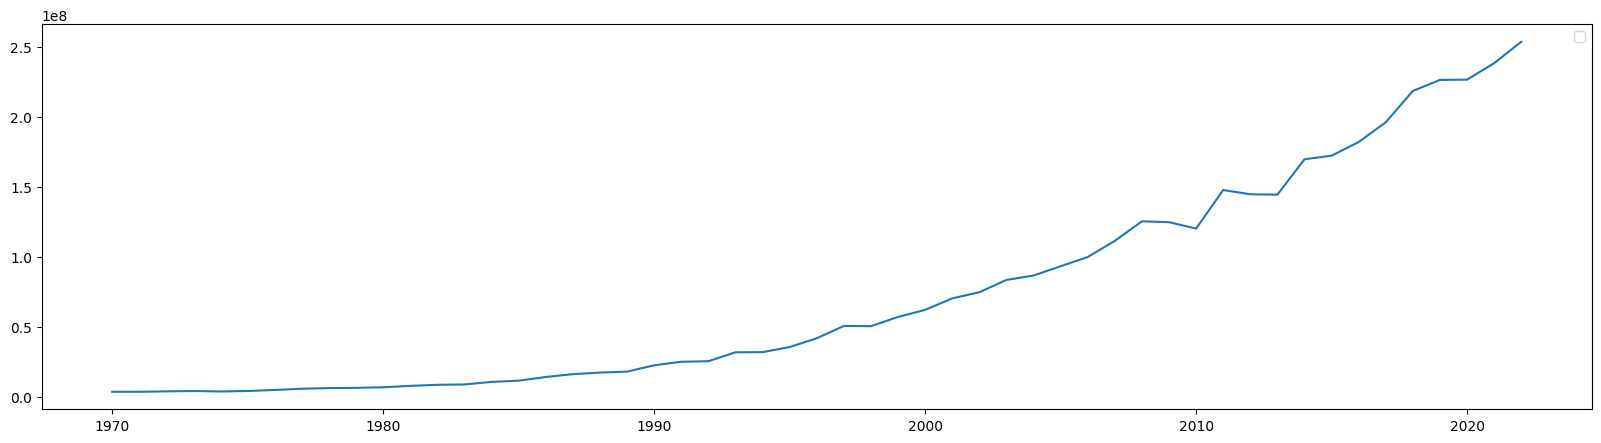

In [215]:
f = plt.figure()
f.set_figwidth(20) 
f.set_figheight(5) 
plt.subplot()
plt.plot(tahun,data["Power Industry"])
plt.legend() 
plt.show()

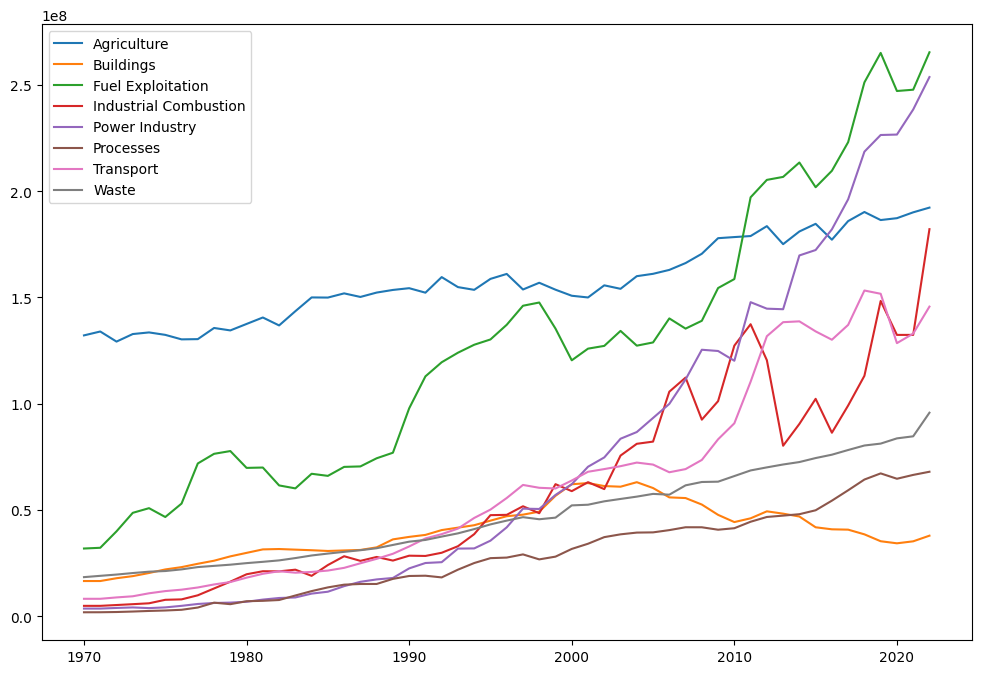

In [209]:
f = plt.figure()
f.set_figwidth(12) 
f.set_figheight(8) 
# plt.subplot()
for i in Kolom:
    plt.plot(tahun,data[i],label=i)
plt.legend() 
plt.show()

# Prepocessing Data

In [163]:
# Normalisasi data dengan min-max scaler
def normalisasi(data):
    test = []
    dmin = min(data)
    dmax = max(data)
    for i in range(len(data)):
        test.append((data[i] - dmin)/(dmax - dmin))
    return test,dmax,dmin

# Sequence untuk x dan  label y
def create_sequences(data, tw):
    x,y= [],[]
    L = len(data)
    for i in range(L-tw):
        train_seq = data[i:i+tw]
        train_label = data[i+tw:i+tw+1]
        x.append(train_seq)
        y.append(train_label)
    return np.expand_dims(np.array(x),-1),np.array(y)

# split
def train_split(data):
    train_size = int(len(data) * 0.7)
    test_size = len(data) - train_size
    train, test = data[:train_size], data[train_size:]
    return np.array(train),np.array(test)

In [164]:
agriculture = df['Agriculture'].to_list()
data_agriculture,max_agriculture,min_agriculture = normalisasi(agriculture)
train_agriculture, test_agriculture = train_split(data_agriculture)
x_agriculture =  create_sequences(data_agriculture, 2)

# dict simpan eval

In [165]:
simpan = {}

# Agriculture

In [166]:
agriculture = df['Agriculture'].to_list()
data_agriculture,max_agriculture,min_agriculture = normalisasi(agriculture)
train_agriculture, test_agriculture = train_split(data_agriculture)
x_agriculture,y_agriculture =  create_sequences(data_agriculture, 1)
x_train_agriculture, y_train_agriculture= create_sequences(train_agriculture, 1)
x_test_agriculture, y_test_agriculture = create_sequences(test_agriculture,1)

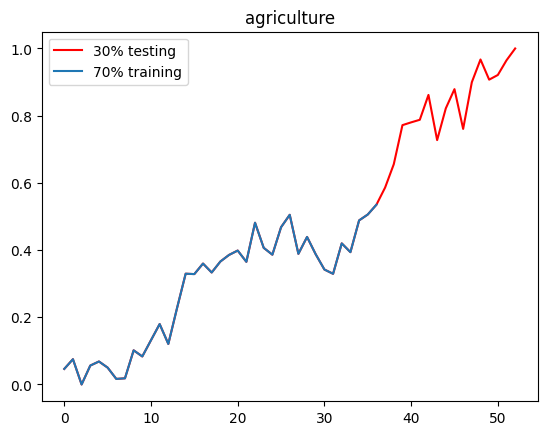

In [167]:
dummy = np.concatenate((train_agriculture, test_agriculture))
plt.plot(dummy,color='red',label = "30% testing")
plt.plot(train_agriculture, label="70% training")
plt.title('agriculture')
plt.legend()
plt.show()

In [168]:
model_agriculture = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1)
])

model_agriculture.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_agriculture = model_agriculture.fit(x_train_agriculture,y_train_agriculture,validation_data=(x_test_agriculture,y_test_agriculture),epochs = 100,verbose=0)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [169]:
model_agriculture.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 2056)           │    16,924,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │         2,057 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,781,149 (193.71 MB)

 Trainable params: 16,927,049 (64.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,854,100 (129.14 MB)

In [170]:
simpan['agriculture'] = [history_agriculture.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

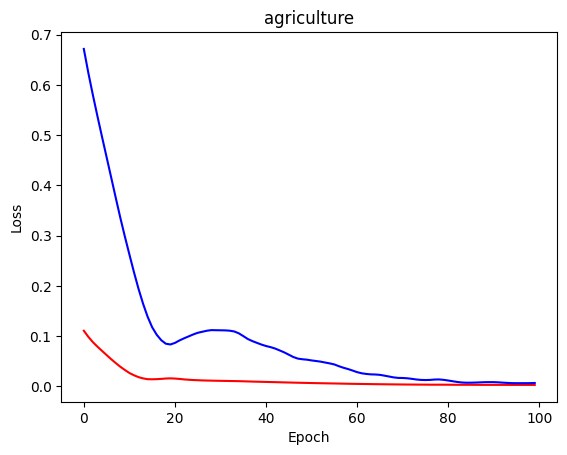

In [171]:
plt.plot(history_agriculture.history['loss'],color='red')
plt.plot(history_agriculture.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('agriculture')
plt.show()

# Buildings

In [172]:
buildings = df['Buildings'].to_list()

In [173]:
data_buildings,max_buildings,min_buildings = normalisasi(buildings)
train_buildings, test_buildings = train_split(data_buildings)
x_buildings,y_buildings =  create_sequences(data_buildings, 1)
x_train_buildings, y_train_buildings= create_sequences(train_buildings, 1)
x_test_buildings, y_test_buildings = create_sequences(test_buildings,1)

In [174]:
model_buildings = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1)
])

model_buildings.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_buildings = model_buildings.fit(x_train_buildings,y_train_buildings,validation_data=(x_test_buildings,y_test_buildings),epochs = 100,verbose=0)

In [175]:
simpan['buildings'] = [history_buildings.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

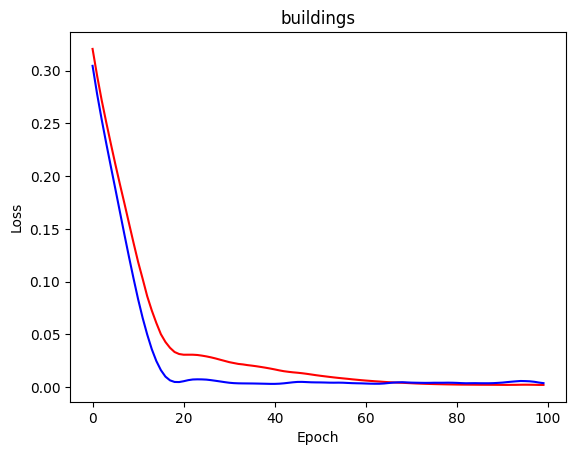

In [176]:
plt.plot(history_buildings.history['loss'],color='red')
plt.plot(history_buildings.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('buildings')
plt.show()

# Fuel Exploitation

In [177]:
fuel = df['Fuel Exploitation'].to_list()
data_fuel,max_fuel,min_fuel = normalisasi(fuel)
train_fuel, test_fuel = train_split(data_fuel)
x_fuel,y_fuel =  create_sequences(data_fuel, 1)
x_train_fuel, y_train_fuel= create_sequences(train_fuel, 1)
x_test_fuel, y_test_fuel = create_sequences(test_fuel,1)

In [178]:
model_fuel = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1)
])

model_fuel.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_fuel = model_fuel.fit(x_train_fuel,y_train_fuel,validation_data=(x_test_fuel,y_test_fuel),epochs = 100,verbose=0)

In [179]:
simpan['fuel'] = [history_fuel.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

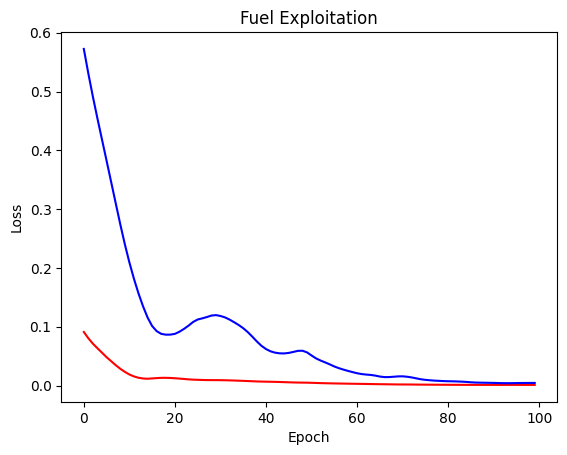

In [180]:
plt.plot(history_fuel.history['loss'],color='red')
plt.plot(history_fuel.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Fuel Exploitation')
plt.show()

# Industrial Combustion

In [181]:
industrial = df['Industrial Combustion'].to_list()
data_industrial,max_industrial,min_industrial = normalisasi(industrial)
train_industrial, test_industrial = train_split(data_industrial)
x_industrial,y_industrial =  create_sequences(data_industrial, 1)
x_train_industrial, y_train_industrial= create_sequences(train_industrial, 1)
x_test_industrial, y_test_industrial = create_sequences(test_industrial,1)

In [182]:
model_industrial = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1,activation='elu')
])

model_industrial.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_industrial = model_industrial.fit(x_train_industrial,y_train_industrial,validation_data=(x_test_industrial,y_test_industrial),epochs = 100,verbose=0)

In [183]:
simpan['industrial'] = [history_industrial.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

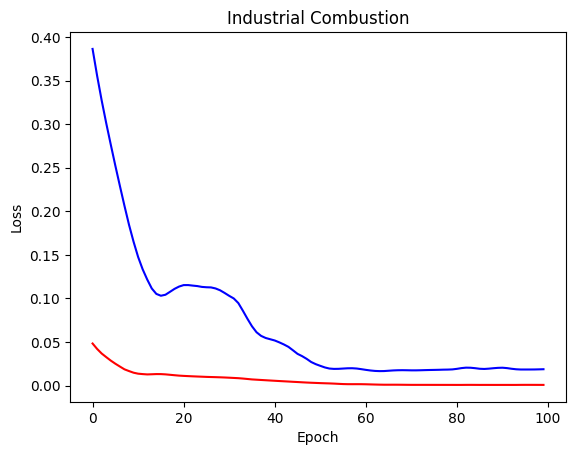

In [184]:
plt.plot(history_industrial.history['loss'],color='red')
plt.plot(history_industrial.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Industrial Combustion')
plt.show()

# Power Industry

In [185]:
power = df['Power Industry'].to_list()
data_power,max_power,min_power = normalisasi(power)
train_power, test_power = train_split(data_power)
x_power,y_power =  create_sequences(data_power, 1)
x_train_power, y_train_power= create_sequences(train_power, 1)
x_test_power, y_test_power = create_sequences(test_power,1)

In [186]:
model_power = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1)
])

model_power.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_power = model_power.fit(x_train_power,y_train_power,validation_data=(x_test_power,y_test_power),epochs = 100,verbose=0)

In [187]:
simpan['power'] = [history_power.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

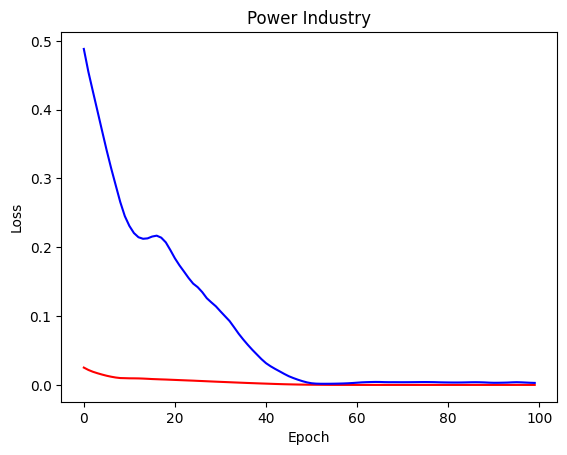

In [188]:
plt.plot(history_power.history['loss'],color='red')
plt.plot(history_power.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Power Industry')
plt.show()

# Processes

In [189]:
processes = df['Processes'].to_list()
data_processes,max_processes,min_processes = normalisasi(processes)
train_processes, test_processes = train_split(data_processes)
x_processes,y_processes =  create_sequences(data_processes, 1)
x_train_processes, y_train_processes= create_sequences(train_processes, 1)
x_test_processes, y_test_processes = create_sequences(test_processes,1)

In [190]:
model_processes = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1)
])

model_processes.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_processes = model_processes.fit(x_train_processes,y_train_processes,validation_data=(x_test_processes,y_test_processes),epochs = 100,verbose=0)

In [191]:
simpan['processes'] = [history_processes.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

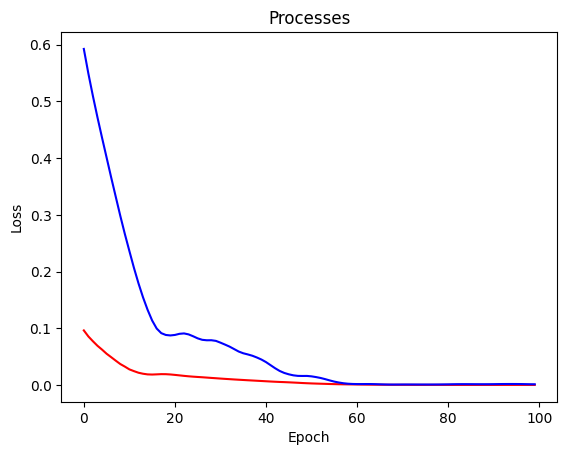

In [192]:
plt.plot(history_processes.history['loss'],color='red')
plt.plot(history_processes.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Processes')
plt.show()

# Transport

In [193]:
transport = df['Transport'].to_list()
data_transport,max_transport,min_transport = normalisasi(transport)
train_transport, test_transport = train_split(data_transport)
x_transport,y_transport =  create_sequences(data_transport, 1)
x_train_transport, y_train_transport= create_sequences(train_transport, 1)
x_test_transport, y_test_transport = create_sequences(test_transport,1)

In [194]:
model_transport = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1)
])

model_transport.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_transport = model_transport.fit(x_train_transport,y_train_transport,validation_data=(x_test_transport,y_test_transport),epochs = 100,verbose=0)

In [195]:
simpan['transport'] = [history_transport.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

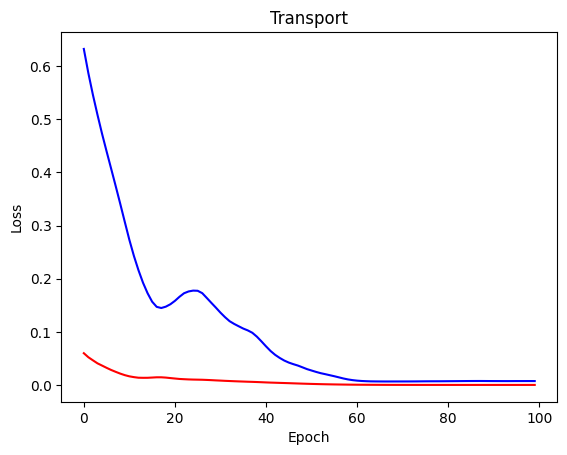

In [196]:
plt.plot(history_transport.history['loss'],color='red')
plt.plot(history_transport.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Transport')
plt.show()

# Waste

In [197]:
waste = df['Waste'].to_list()
data_waste,max_waste,min_waste = normalisasi(waste)
train_waste, test_waste = train_split(data_waste)
x_waste,y_waste =  create_sequences(data_waste, 1)
x_train_waste, y_train_waste= create_sequences(train_waste, 1)
x_test_waste, y_test_waste = create_sequences(test_waste,1)

In [198]:
model_waste = Sequential([
tf.keras.layers.LSTM(2056, input_shape=(1, 1),activation='relu'),
 
tf.keras.layers.Dense(1)
])

model_waste.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(),metrics=['mse',tf.keras.metrics.RootMeanSquaredError(),'mae','mape'])
history_waste = model_waste.fit(x_train_waste,y_train_waste,validation_data=(x_test_waste,y_test_waste),epochs = 100,verbose=0)

In [199]:
simpan['waste'] = [history_waste.history[i][-1] for i in ['mse','root_mean_squared_error','mae','mape','val_mse','val_root_mean_squared_error','val_mae','val_mape']]

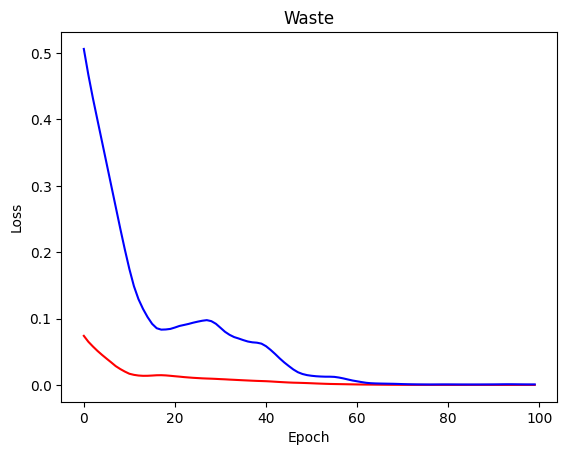

In [200]:
plt.plot(history_waste.history['loss'],color='red')
plt.plot(history_waste.history['val_loss'],color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Waste')
plt.show()

# Plot

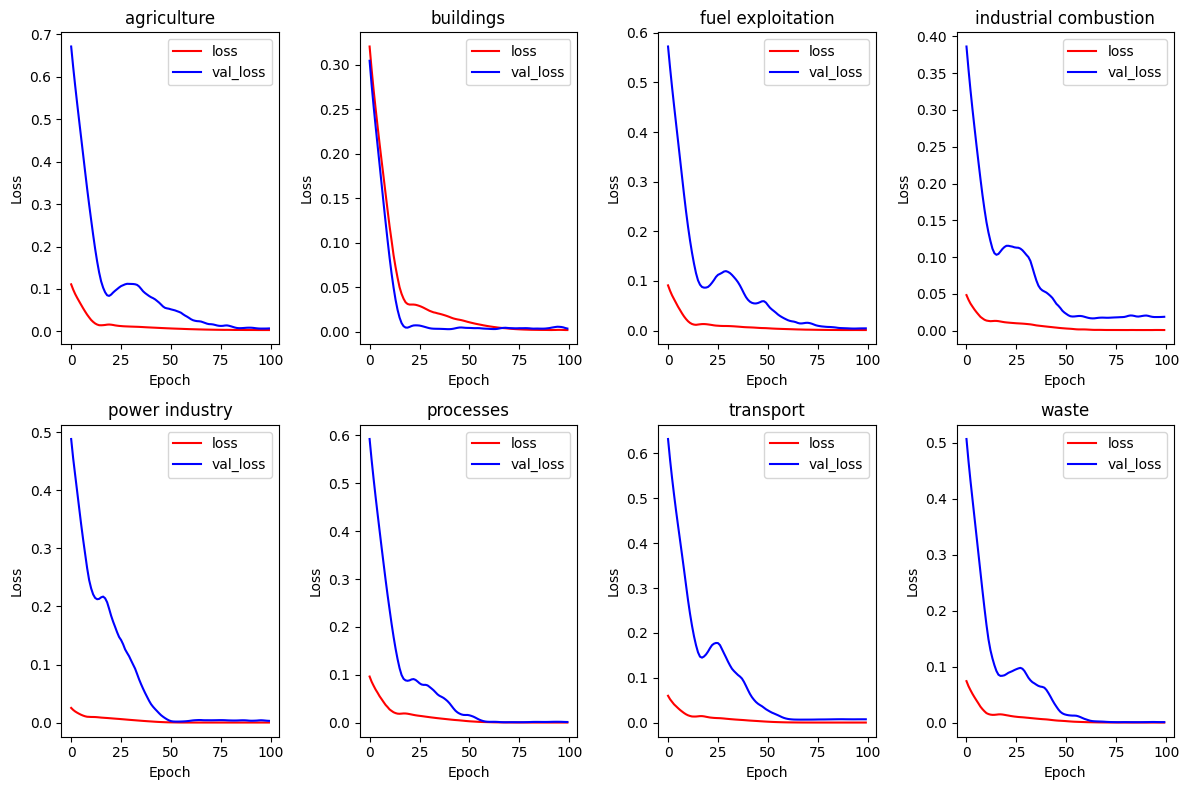

In [201]:
f = plt.figure()
f.set_figwidth(12) 
f.set_figheight(8) 

plt.subplot(2,4,1)
plt.plot(history_agriculture.history['loss'],color='red',label='loss')
plt.plot(history_agriculture.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('agriculture')

plt.subplot(2,4,2)
plt.plot(history_buildings.history['loss'],color='red',label='loss')
plt.plot(history_buildings.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('buildings')

plt.subplot(2,4,3)
plt.plot(history_fuel.history['loss'],color='red',label='loss')
plt.plot(history_fuel.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('fuel exploitation')

plt.subplot(2,4,4)
plt.plot(history_industrial.history['loss'],color='red',label='loss')
plt.plot(history_industrial.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('industrial combustion')

plt.subplot(2,4,5)
plt.plot(history_power.history['loss'],color='red',label='loss')
plt.plot(history_power.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('power industry')

plt.subplot(2,4,6)
plt.plot(history_processes.history['loss'],color='red',label='loss')
plt.plot(history_processes.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('processes')

plt.subplot(2,4,7)
plt.plot(history_transport.history['loss'],color='red',label='loss')
plt.plot(history_transport.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('transport')

plt.subplot(2,4,8)
plt.plot(history_waste.history['loss'],color='red',label='loss')
plt.plot(history_waste.history['val_loss'],color='blue',label='val_loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('waste')

f.tight_layout()
plt.show()


# plot data aktual dan prediksi model

In [202]:
def invers_normalisasi(data,dmax,dmin):
    for i in range(len(data)):
        temp = []
        temp.append(data[i])*(dmax - dmin) + dmin
    return np.array(temp)
def prediksi(data,x_train,x_test,model):
    train_plot = np.ones_like(data) * np.nan
    test_plot = np.ones_like(data) * np.nan
    train_size = len(x_train) + 1
    y_pred_train = model.predict(x_train).reshape(-1)
    y_pred_test = model.predict(x_test).reshape(-1)
    train_plot[1:train_size] = y_pred_train
    test_plot[train_size+1:len(data)] = y_pred_test
    return train_plot,test_plot

In [203]:

pred_train_agriculture, pred_test_agriculture = prediksi(data_agriculture,x_train_agriculture,x_test_agriculture,model_agriculture)
# train_agriculture, test_agriculture = invers_normalisasi(train_agriculture,max_agriculture,min_agriculture),invers_normalisasi(test_agriculture,max_agriculture,min_agriculture)

pred_train_buildings, pred_test_buildings = prediksi(data_buildings,x_train_buildings,x_test_buildings,model_buildings)
# train_buildings, test_buildings = invers_normalisasi(train_buildings,max_buildings,min_buildings), invers_normalisasi(test_buildings,max_buildings,min_buildings)

pred_train_fuel, pred_test_fuel = prediksi(data_fuel,x_train_fuel,x_test_fuel,model_fuel)
# train_fuel, test_fuel = invers_normalisasi(train_fuel,max_fuel,min_fuel),invers_normalisasi(test_fuel,max_fuel,min_fuel)


pred_train_industrial, pred_test_industrial = prediksi(data_industrial,x_train_industrial,x_test_industrial,model_industrial)
# train_industrial, test_industrial = invers_normalisasi(train_industrial,max_industrial,min_industrial),invers_normalisasi(test_industrial,max_industrial,min_industrial)


pred_train_power, pred_test_power = prediksi(data_power,x_train_power,x_test_power,model_power)
# train_power, test_power = invers_normalisasi(train_power,max_power,min_power),invers_normalisasi(test_power,max_power,min_power)


pred_train_processes, pred_test_processes = prediksi(data_processes,x_train_processes,x_test_processes,model_processes)
# train_processes, test_processes = invers_normalisasi(train_processes,max_processes,min_processes),invers_normalisasi(test_processes,max_processes,min_processes)


pred_train_transport, pred_test_transport = prediksi(data_transport,x_train_transport,x_test_transport,model_transport)
# train_transport, test_transport = invers_normalisasi(train_transport,max_transport,min_transport),invers_normalisasi(test_transport,max_transport,min_transport)


pred_train_waste, pred_test_waste = prediksi(data_waste,x_train_waste,x_test_waste,model_waste)
# train_waste, test_waste = invers_normalisasi(train_waste,max_waste,min_waste),invers_normalisasi(test_waste,max_waste,min_waste)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


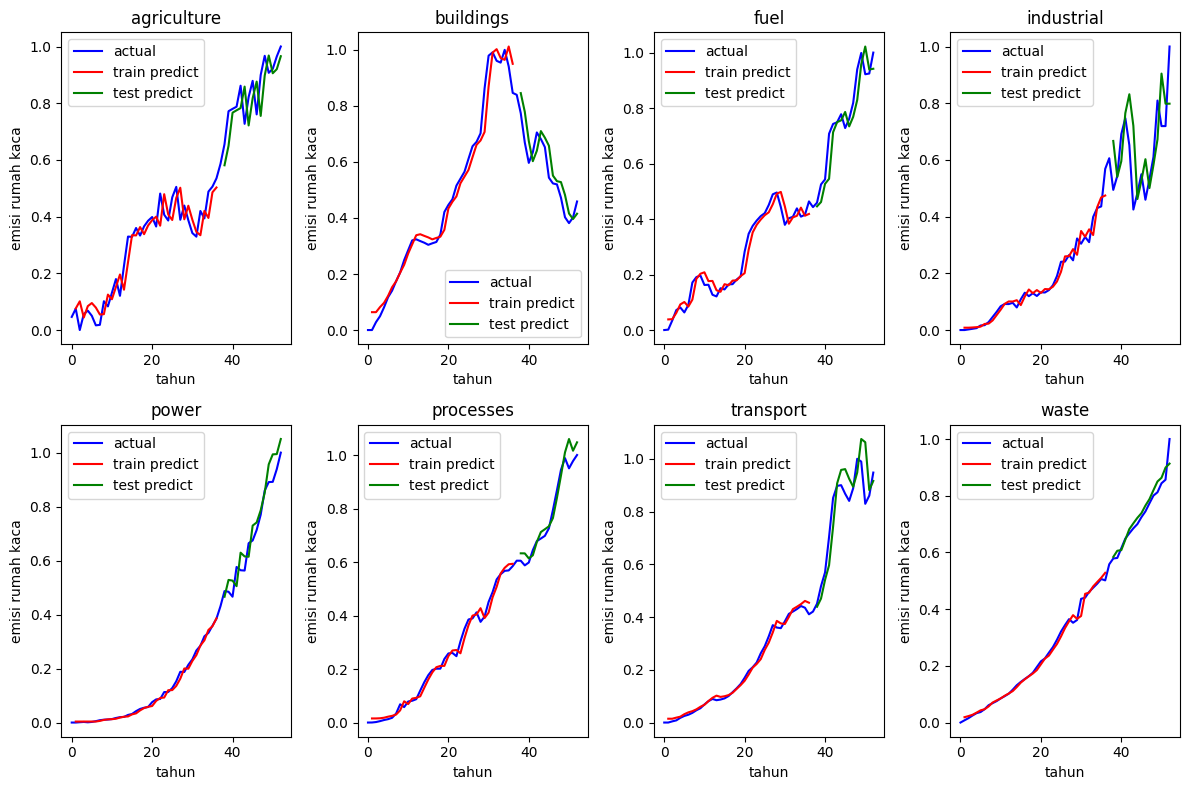

In [204]:
f = plt.figure()
f.set_figwidth(12) 
f.set_figheight(8) 

plt.subplot(2,4,1)
plt.plot(data_agriculture,color='blue',label ='actual')
plt.plot(pred_train_agriculture, color='red', label = 'train predict')
plt.plot(pred_test_agriculture,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('agriculture')
plt.legend()

plt.subplot(2,4,2)
plt.plot(data_buildings,color='blue',label ='actual')
plt.plot(pred_train_buildings, color='red', label = 'train predict')
plt.plot(pred_test_buildings,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('buildings')
plt.legend()

plt.subplot(2,4,3)
plt.plot(data_fuel,color='blue',label ='actual')
plt.plot(pred_train_fuel, color='red', label = 'train predict')
plt.plot(pred_test_fuel,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('fuel')
plt.legend()

plt.subplot(2,4,4)
plt.plot(data_industrial,color='blue',label ='actual')
plt.plot(pred_train_industrial, color='red', label = 'train predict')
plt.plot(pred_test_industrial,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('industrial')
plt.legend()

plt.subplot(2,4,5)
plt.plot(data_power,color='blue',label ='actual')
plt.plot(pred_train_power, color='red', label = 'train predict')
plt.plot(pred_test_power,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('power')
plt.legend()

plt.subplot(2,4,6)
plt.plot(data_processes,color='blue',label ='actual')
plt.plot(pred_train_processes, color='red', label = 'train predict')
plt.plot(pred_test_processes,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('processes')
plt.legend()

plt.subplot(2,4,7)
plt.plot(data_transport,color='blue',label ='actual')
plt.plot(pred_train_transport, color='red', label = 'train predict')
plt.plot(pred_test_transport,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('transport')
plt.legend()

plt.subplot(2,4,8)
plt.plot(data_waste,color='blue',label ='actual')
plt.plot(pred_train_waste, color='red', label = 'train predict')
plt.plot(pred_test_waste,  color = 'green', label = 'test predict')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('waste')
plt.legend()

f.tight_layout()
plt.show()

# Evaluasi

In [205]:
tabel_evaluasi = pd.DataFrame(simpan)
tabel_evaluasi.index = ['mse', 'rmse', 'mae','mape','val_mse','val_rmse','val_mae','val_mape']

In [206]:
tabel_evaluasi

,agriculture,buildings,fuel,industrial,power,processes,transport,waste
mse,3.121621e-03,2.105129e-03,0.001024,0.000794,0.000070,0.000400,0.000211,0.000189
rmse,5.587147e-02,4.588168e-02,0.032002,0.028179,0.008389,0.020007,0.014512,0.013757
mae,4.643715e-02,3.136037e-02,0.024243,0.018738,0.005852,0.016547,0.011236,0.008310
mape,2.892021e+06,1.803860e+06,82.539764,224150.359375,105110.000000,248.581161,2295.131348,8.925807
val_mse,6.951252e-03,3.795800e-03,0.004423,0.018775,0.002996,0.001534,0.007461,0.000943
val_rmse,8.337416e-02,6.161006e-02,0.066503,0.137023,0.054739,0.039168,0.086379,0.030706
val_mae,7.198071e-02,5.274558e-02,0.051145,0.107476,0.049587,0.030888,0.065157,0.023423
val_mape,8.788999e+00,9.490514e+00,6.637877,18.166508,7.447017,3.867011,8.090437,2.972637


# Prediksi Beberapa Tahun Kedepan

In [207]:
def prediksi_beberapa_tahun(data,model,tahun):
    hasil = []
    y_last = np.array(data[-1]).reshape(1,1,1)
    for i in range(tahun):
        temp = model.predict(y_last,verbose=0).reshape(-1)
        hasil.append(temp[-1])
        y_last = np.array(temp).reshape(1,1,1)
    return data + hasil

# Plot prediksi 3 tahun kedepan

In [208]:
pred_agriculture = invers_normalisasi(prediksi_beberapa_tahun(data_agriculture,model_agriculture,3),max_agriculture,min_agriculture)
pred_buildings = invers_normalisasi(prediksi_beberapa_tahun(data_buildings,model_buildings,3),max_buildings,min_buildings)
pred_fuel = invers_normalisasi(prediksi_beberapa_tahun(data_fuel,model_fuel,3),max_fuel,min_fuel)
pred_industrial = invers_normalisasi(prediksi_beberapa_tahun(data_industrial,model_industrial,3),max_industrial,min_industrial)
pred_power = invers_normalisasi(prediksi_beberapa_tahun(data_power,model_power,3),max_power,min_power)
pred_processes = invers_normalisasi(prediksi_beberapa_tahun(data_processes,model_processes,3),max_processes,min_processes)
pred_transport = invers_normalisasi(prediksi_beberapa_tahun(data_transport,model_transport,3),max_transport,min_transport)
pred_waste = invers_normalisasi(prediksi_beberapa_tahun(data_waste,model_waste,3),max_waste,min_waste)

TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

In [ ]:
f = plt.figure()
f.set_figwidth(12) 
f.set_figheight(8) 

plt.subplot(2,4,1)
plt.plot(pred_agriculture, label = 'predict',color='red')
plt.plot(agriculture,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('agriculture')
plt.legend()

plt.subplot(2,4,2)
plt.plot(pred_buildings, label = 'predict',color='red')
plt.plot(buildings,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('buildings')
plt.legend()

plt.subplot(2,4,3)
plt.plot(pred_fuel, label = 'predict',color='red')
plt.plot(fuel,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('fuel')
plt.legend()

plt.subplot(2,4,4)
plt.plot(pred_industrial, label = 'predict',color='red')
plt.plot(industrial,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('industrial')
plt.legend()

plt.subplot(2,4,5)
plt.plot(pred_power, label = 'predict',color='red')
plt.plot(power,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('power')
plt.legend()

plt.subplot(2,4,6)
plt.plot(pred_processes, label = 'predict',color='red')
plt.plot(processes,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('processes')
plt.legend()

plt.subplot(2,4,7)
plt.plot(pred_transport, label = 'predict',color='red')
plt.plot(transport,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('transport')
plt.legend()

plt.subplot(2,4,8)
plt.plot(pred_waste, label = 'predict',color='red')
plt.plot(waste,color='blue', label = 'actual')
plt.xlabel('tahun')
plt.ylabel('emisi rumah kaca')
plt.title('waste')
plt.legend()

f.tight_layout()
plt.show()

# Mape

In [ ]:
def prediksi_all_mape(x_data,data, model,dmax,dmin):
    test = model.predict(x_data,verbose=0)
    test_train_plot = np.ones_like(data) * np.nan
    test_train_plot[1:] = test.reshape(-1)
    test_train_plot = invers_normalisasi(test_train_plot,dmax,dmin)
    data_1 = invers_normalisasi(data,dmax,dmin)
    return float(tf.keras.metrics.mean_absolute_percentage_error(data_1[1:],test_train_plot[1:]))

In [ ]:
# simpan dalam dataframe
tabel_evaluasi = pd.DataFrame(simpan)
tabel_evaluasi.index = ['mse', 'rmse', 'mae','mape', 'val_mse','val_rmse','val_mae','val_mape']

In [ ]:
# train mape
train_mape_agriculture = prediksi_all_mape(x_train_agriculture,train_agriculture,model_agriculture,max_agriculture,min_agriculture)
train_mape_buildings = prediksi_all_mape(x_train_buildings,train_buildings,model_buildings,max_buildings,min_buildings)
train_mape_fuel = prediksi_all_mape(x_train_fuel,train_fuel,model_fuel,max_fuel,min_fuel)
train_mape_industrial = prediksi_all_mape(x_train_industrial,train_industrial,model_industrial,max_industrial,min_industrial)
train_mape_power = prediksi_all_mape(x_train_power,train_power,model_power,max_power,min_power)
train_mape_processes = prediksi_all_mape(x_train_processes,train_processes,model_processes,max_processes,min_processes)
train_mape_transport = prediksi_all_mape(x_train_transport,train_transport,model_transport,max_transport,min_transport)
train_mape_waste = prediksi_all_mape(x_train_waste,train_waste,model_waste,max_waste,min_waste)
tabel_evaluasi.iloc[3,:] = [train_mape_agriculture,train_mape_buildings,train_mape_fuel,train_mape_industrial,
                 train_mape_power,train_mape_processes ,train_mape_transport,train_mape_waste]

In [ ]:
print(train_mape_buildings)

In [ ]:
val_mape_agriculture = prediksi_all_mape(x_test_agriculture,test_agriculture,model_agriculture,max_agriculture,min_agriculture)
val_mape_buildings = prediksi_all_mape(x_test_buildings,test_buildings,model_buildings,max_buildings,min_buildings)
val_mape_fuel = prediksi_all_mape(x_test_fuel,test_fuel,model_fuel,max_fuel,min_fuel)
val_mape_industrial = prediksi_all_mape(x_test_industrial,test_industrial,model_industrial,max_industrial,min_industrial)
val_mape_power = prediksi_all_mape(x_test_power,test_power,model_power,max_power,min_power)
val_mape_processes = prediksi_all_mape(x_test_processes,test_processes,model_processes,max_processes,min_processes)
val_mape_transport = prediksi_all_mape(x_test_transport,test_transport,model_transport,max_transport,min_transport)
val_mape_waste = prediksi_all_mape(x_test_waste,test_waste,model_waste,max_waste,min_waste)
tabel_evaluasi.iloc[7,:] = [val_mape_agriculture,val_mape_buildings,val_mape_fuel,val_mape_industrial,
                 val_mape_power,val_mape_processes ,val_mape_transport,val_mape_waste]

In [ ]:
tabel_evaluasi